# 使用Scikit-Learn 完成預測
### Scikit-Learn在三個面向提供支援。
1. 獲取資料:***klearn.datasets***
2. 掌握資料:***sklearn.preprocessing*** 
3. 機器學習:***sklearn Estimator API*** 

獲取資料的方式有很多種（包含檔案、資料庫、網路爬蟲、Kaggle Datasets等），<br>
其中最簡單的方式是從Sklearn import 內建的資料庫。由於其特性隨手可得且不用下載，所以我們通常叫他**玩具資料**：

# 基本架構

* 讀取資料&pre-processing
* 切分訓練集與測試集 
* 模型配適
* 預測 
* 評估(計算成績可能是誤差值或正確率或..)


In [20]:
%matplotlib inline

from sklearn import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 讀取Iris資料集與資料前處理

Iris Flowers 資料集

我們在這個項目中使用 Iris Data Set，這個資料集中的每個樣本有4個特徵，1個類別。該資料集1中的樣本類別數為3類，每類樣本數目為50個，總共150個樣本。

屬性資訊：

    花萼長度 sepal length(cm)
    花萼寬度 sepal width(cm)
    花瓣長度 petal length(cm)
    花瓣寬度 petal width(cm)
    類別：
        Iris Setosa
        Iris Versicolour
        Iris Virginica

樣本特徵資料是數值型的，而且單位都相同（釐米）。

![Iris Flowers](images/iris_data.PNG)


In [21]:
iris = datasets.load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

* 印出iris的key值與檔案位置
* 查看前10筆資料
* 查看資料型別
* 印出標註的樣本類別資料

In [22]:
print(iris.keys())
print(iris['filename'])
print(iris.data[0:10])
print(type(iris.data))
print(iris.target_names)
print(iris.target)

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
iris.csv
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]
<class 'numpy.ndarray'>
['setosa' 'versicolor' 'virginica']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [23]:
# we only take the first two features. 
X = iris.data[:,:2]
print(X.shape)
Y = iris.target
print(Y.shape)

(150, 2)
(150,)


In [25]:
# 以下是組成 pandas DataFrame (也可以不用這種做)

x = pd.DataFrame(iris.data, columns=iris['feature_names'])

x.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


In [26]:
print("target_names: " + str(iris['target_names']))

target_names: ['setosa' 'versicolor' 'virginica']


In [14]:
#建立Target欄位與資料
y = pd.DataFrame(iris['target'], columns=['target'])

# 顯示前 5 筆資料
y.head()

,target
0,0
1,0
2,0
3,0
4,0


In [27]:
#合併資料特徵欄位與目標欄位

iris_data = pd.concat([x,y],axis=1)

iris_data = iris_data[['sepal length (cm)','petal length (cm)','target']]

iris_data.head(10)

,sepal length (cm),petal length (cm),target
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0
5,5.4,1.7,0
6,4.6,1.4,0
7,5.0,1.5,0
8,4.4,1.4,0
9,4.9,1.5,0


In [28]:
#只選擇目標為0與1的資料
iris_data = iris_data[iris_data['target'].isin([0, 1])]

iris_data

#print(iris['data'].size)

,sepal length (cm),petal length (cm),target
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0
...,...,...,...
95,5.7,4.2,1
96,5.7,4.2,1
97,6.2,4.3,1
98,5.1,3.0,1


## 切分訓練集與測試集
> train_test_split()

In [29]:
from sklearn.model_selection import train_test_split

 

X_train, X_test, Y_train, Y_test = train_test_split(

    iris_data[['sepal length (cm)', 'petal length (cm)']],

    iris_data['target'],

    test_size=0.3

)

In [30]:
X_train.head()

X_train.shape

(70, 2)

In [23]:
X_test.head()

,sepal length (cm),petal length (cm)
39,5.1,1.5
81,5.5,3.7
15,5.7,1.5
80,5.5,3.8
73,6.1,4.7


# Appendix 

>normalization和standardization是差不多的<br>
都是把數據進行前處理，從而使數值都落入到統一的數值範圍，從而在建模過程中，各個特徵量沒差別對待。<br> 
* normalization一般是把數據限定在需要的範圍，比如一般都是【0，1】，從而消除了數據量綱對建模的影響。<br> 
* standardization 一般是指將數據正態化，使平均值0方差為1.<br> 

因此normalization和standardization 是針對數據而言的，消除一些數值差異帶來的特種重要性偏見。<br>
經過歸一化的數據，能加快訓練速度，促進算法的收斂。

### Standardization (z-score)
    to compute the mean and standard deviation on a training set so as to be able to later reapply the same transformation on the testing set. 

In [33]:
def norm_stats(df):
    # 加入 axis=0 確保計算每一欄的值
    minimum = np.min(df, axis=0)
    maximum = np.max(df, axis=0)
    mu = np.mean(df, axis=0)
    sigma = np.std(df, axis=0)

    return (minimum, maximum, mu, sigma)

 

def z_score(col, stats):

    m, M, mu, s = stats

    df = pd.DataFrame()

    for c in col.columns:

        df[c] = (col[c] - mu[c]) / s[c]

    return df

 

In [34]:
stats = norm_stats(X_train)

arr_x_train = np.array(z_score(X_train, stats))

arr_x_train

 

stats = norm_stats(X_test)

arr_x_test = np.array(z_score(X_test, stats))

arr_x_test

 

# arr_y_train = np.array(Y_train)

array([[-0.04059011,  1.09514235],
       [-1.43225112, -1.34108533],
       [-0.21454774, -0.99305281],
       [ 1.00315564,  1.51278138],
       [-0.56246299, -0.71462679],
       [ 0.48128276,  0.81671633],
       [-1.43225112, -1.06265931],
       [-0.04059011, -1.13226582],
       [-0.04059011, -0.99305281],
       [ 0.48128276,  0.88632283],
       [ 1.00315564,  0.74710982],
       [-0.73642062, -1.06265931],
       [-0.73642062, -0.9234463 ],
       [-0.56246299, -0.9234463 ],
       [-0.91037824, -0.99305281],
       [ 1.17711327,  1.23435536],
       [ 1.35107089,  0.95592934],
       [ 1.69898614,  1.09514235],
       [ 2.22085902,  1.23435536],
       [ 0.13336751,  1.02553584],
       [-0.91037824, -1.06265931],
       [-0.38850536, -1.06265931],
       [ 0.30732514,  0.88632283],
       [-1.78016637, -1.06265931],
       [ 0.13336751,  0.60789681],
       [ 0.30732514,  0.67750332],
       [-0.73642062,  0.25986429],
       [ 1.87294377,  1.16474885],
       [-0.73642062,

## use sklearn

In [35]:
from sklearn.preprocessing import StandardScaler

 

# 1. 建立標準化器並計算統計量 (計算平均值與標準差)

sc = StandardScaler().fit(X_train)

 

# 2. 印出計算好的平均值 (mean)

print(sc.mean_)

 

# 3. 印出計算好的標準差 (standard deviation)

print(sc.scale_)

[5.49142857 2.83285714]
[0.66283867 1.44377693]


In [36]:
# transform: (x-u)/std. 套用公式進行轉換

X_train_std = sc.transform(X_train)

 

# 顯示轉換後的前 5 筆資料

X_train_std[:5]

array([[ 2.2759255 ,  1.293235  ],
       [-1.04313252, -0.85391109],
       [ 0.46553022,  0.87765833],
       [ 1.21986158,  1.08544666],
       [-0.89226625, -0.92317387]])

The scaler instance can then be used on new data to transform it the same way it did on the training set:

In [37]:
X_test_std = sc.transform(X_test)

print(X_test_std[:10])

 

[[-0.13793488  1.15470944]
 [-1.34486507 -1.26948776]
 [-0.28880115 -0.92317387]
 [ 0.76726276  1.5702861 ]
 [-0.5905337  -0.64612276]
 [ 0.31466394  0.87765833]
 [-1.34486507 -0.99243665]
 [-0.13793488 -1.06169943]
 [-0.13793488 -0.92317387]
 [ 0.31466394  0.94692111]]


you can also use fit_transform method (i.e., fit and then transform)    

In [38]:
X_train_std = sc.fit_transform(X_train)

X_test_std = sc.transform(X_test)

print(X_test_std[:10])

[[-0.13793488  1.15470944]
 [-1.34486507 -1.26948776]
 [-0.28880115 -0.92317387]
 [ 0.76726276  1.5702861 ]
 [-0.5905337  -0.64612276]
 [ 0.31466394  0.87765833]
 [-1.34486507 -0.99243665]
 [-0.13793488 -1.06169943]
 [-0.13793488 -0.92317387]
 [ 0.31466394  0.94692111]]


In [39]:
print('mean of X_train_std:',np.round(X_train_std.mean(),4))
print('std of X_train_std:',X_train_std.std())

mean of X_train_std: -0.0
std of X_train_std: 1.0


## Min-Max Normaliaztion
    Transforms features by scaling each feature to a given range.
    The transformation is given by:

    X' = X - X.min(axis=0) / ((X.max(axis=0) - X.min(axis=0))
    X -> N 維資料
    


48.77067516760747
29.883305634910048


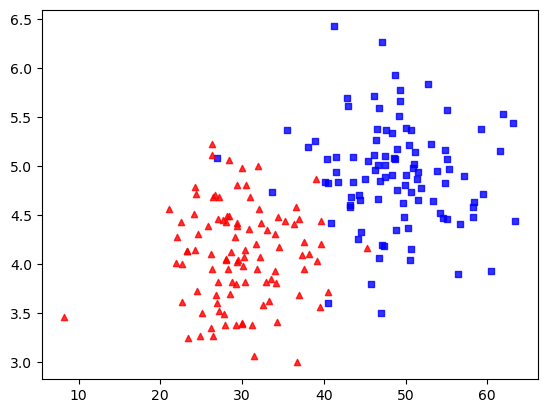

In [40]:
# 生成第一組數據 (x1, y1)

x1 = np.random.normal(50, 6, 100) # np.random.normal(mu, sigma, size)

y1 = np.random.normal(5, 0.5, 100)

 

# 生成第二組數據 (x2, y2)

x2 = np.random.normal(30, 6, 100)

y2 = np.random.normal(4, 0.5, 100)

 

# 繪製散佈圖

plt.scatter(x1, y1, c='b', marker='s', s=20, alpha=0.8) # 藍色 方塊

plt.scatter(x2, y2, c='r', marker='^', s=20, alpha=0.8) # 紅色 三角形

 

# 計算並印出 x1 和 x2 的平均值

print(np.sum(x1)/len(x1))

print(np.sum(x2)/len(x2))

In [41]:
x_val = np.concatenate((x1, x2))

y_val = np.concatenate((y1, y2))

 

x_val.shape

(200,)

In [42]:
def minmax_norm(X):

    return (X - X.min(axis=0)) / ((X.max(axis=0) - X.min(axis=0)))

In [43]:
minmax_norm(x_val[:10])

array([1.        , 0.        , 0.58748702, 0.97109896, 0.76953837,
       0.527777  , 0.71445596, 0.07939488, 0.72872141, 0.71481579])

In [44]:
from sklearn.preprocessing import MinMaxScaler

 

# 1. 顯示原始形狀 (應該是一維，例如 (100,))

print(x_val.shape)

 

# 2. 進行維度轉換：從 1D 變成 2D (#1D -> >2D)

x_val = x_val.reshape(-1, 1)

 

# 3. 顯示轉換後的形狀 (應該會變成 (100, 1))

print(x_val.shape)

 

# 4. 建立並擬合縮放器

scaler = MinMaxScaler().fit(x_val) # 預設範圍 0-1

 

# 5. 印出數據中的最大值

print(scaler.data_max_)

 

# 6. 執行轉換並印出前 10 筆

print(scaler.transform(x_val)[:10])

(200,)
(200, 1)
[63.42361765]
[[0.8537574 ]
 [0.55496168]
 [0.73050029]
 [0.84512189]
 [0.78489645]
 [0.71265919]
 [0.76843807]
 [0.57868453]
 [0.77270052]
 [0.76854558]]
